In [4]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


Accuracy: 0.6735
Confusion Matrix:
[[1257  356]
 [ 297   90]]
Precision: 0.6914090543137629
Recall: 0.6735
F1 Score: 0.6820214399621547


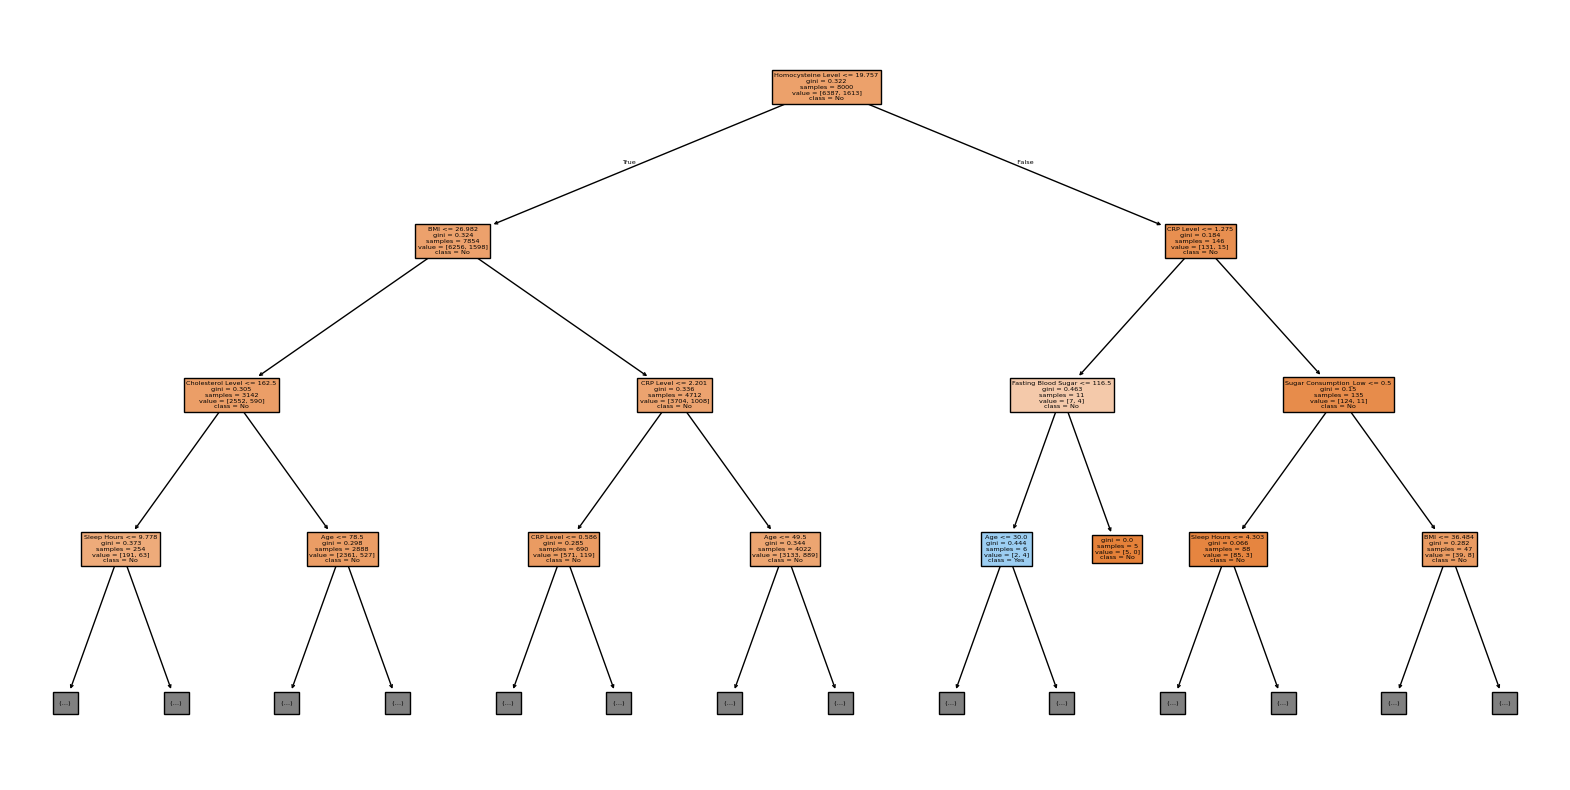

In [5]:
# 1. Import required libraries

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

from sklearn.preprocessing import LabelEncoder


# 2. Load the dataset

df = pd.read_csv(
    "/content/drive/MyDrive/BML_Semester5_Diploma/BML/archive/heart_disease.csv"
)

target_col = 'Heart Disease Status'


# Handle missing values

num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])


# 3. Separate input features X and target y

X = df.drop(columns=[target_col])
y = df[target_col]


# 4. Convert categorical data into numerical labels

# Convert categorical columns in X

X = pd.get_dummies(X, drop_first=True)


# Convert target variable into numerical labels

le = LabelEncoder()
y = le.fit_transform(y)


# 5. Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# 6. Create Decision Tree Classifier

model = DecisionTreeClassifier(random_state=42)


# 7. Train the model

model.fit(X_train, y_train)


# 8. Predict results

y_pred = model.predict(X_test)


# 9. Evaluate the model

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

precision = precision_score(y_test, y_pred, average='weighted')
print("Precision:", precision)

recall = recall_score(y_test, y_pred, average='weighted')
print("Recall:", recall)

f1 = f1_score(y_test, y_pred, average='weighted')
print("F1 Score:", f1)


# 10. Visualize the Decision Tree

plt.figure(figsize=(20, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=le.classes_,
    filled=True,
    max_depth=3
)

plt.show()